In [25]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

In [26]:
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [27]:
X_train

array([[1.374e+01, 1.791e+01, 8.812e+01, ..., 6.019e-02, 2.350e-01,
        7.014e-02],
       [1.337e+01, 1.639e+01, 8.610e+01, ..., 8.978e-02, 2.048e-01,
        7.628e-02],
       [1.469e+01, 1.398e+01, 9.822e+01, ..., 1.108e-01, 2.827e-01,
        9.208e-02],
       ...,
       [1.429e+01, 1.682e+01, 9.030e+01, ..., 3.333e-02, 2.458e-01,
        6.120e-02],
       [1.398e+01, 1.962e+01, 9.112e+01, ..., 1.827e-01, 3.179e-01,
        1.055e-01],
       [1.218e+01, 2.052e+01, 7.722e+01, ..., 7.431e-02, 2.694e-01,
        6.878e-02]], shape=(398, 30))

In [28]:
len(y_train)

398

In [29]:
xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    eval_metric='logloss',
    random_state=42
)

In [30]:
xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [31]:
y_pred = xgb.predict(X_test)

In [32]:
y_test

array([1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1])

In [33]:
y_pred

array([1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1,
       0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1])

In [34]:
print(f"XGBoost 准确率: {accuracy_score(y_test, y_pred):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['恶性', '良性']))

XGBoost 准确率: 0.9532

              precision    recall  f1-score   support

          恶性       0.95      0.92      0.94        63
          良性       0.95      0.97      0.96       108

    accuracy                           0.95       171
   macro avg       0.95      0.95      0.95       171
weighted avg       0.95      0.95      0.95       171



In [35]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

In [36]:
X_tr

array([[1.291e+01, 1.633e+01, 8.253e+01, ..., 8.235e-02, 3.024e-01,
        6.949e-02],
       [1.285e+01, 2.137e+01, 8.263e+01, ..., 5.601e-02, 2.488e-01,
        8.151e-02],
       [1.133e+01, 1.416e+01, 7.179e+01, ..., 1.111e-02, 2.758e-01,
        6.386e-02],
       ...,
       [1.742e+01, 2.556e+01, 1.145e+02, ..., 1.099e-01, 1.603e-01,
        6.818e-02],
       [1.630e+01, 1.570e+01, 1.047e+02, ..., 1.357e-01, 2.300e-01,
        7.230e-02],
       [1.747e+01, 2.468e+01, 1.161e+02, ..., 1.721e-01, 2.160e-01,
        9.300e-02]], shape=(318, 30))

In [37]:
xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    eval_metric='logloss',
    random_state=42,
    early_stopping_rounds=10  # 早停放这里
)

xgb.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False
)
# best_iteration是0起始，+1转成第几轮
print(f"最优训练轮数: {xgb.best_iteration + 1}")

最优训练轮数: 71


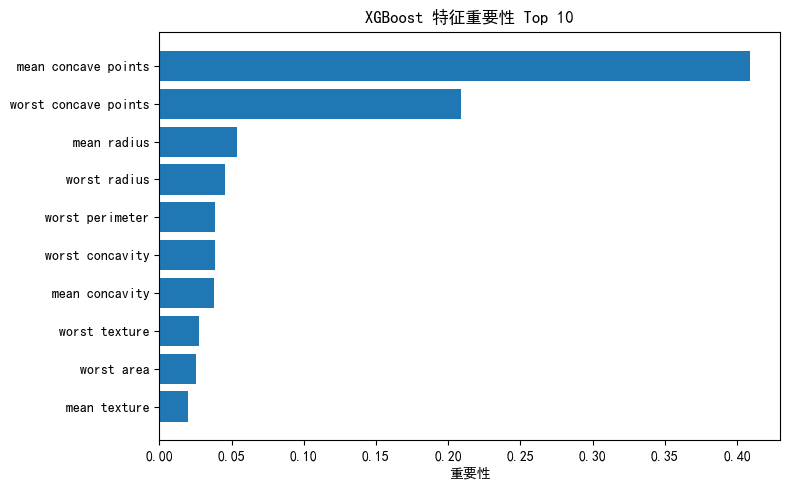

In [39]:
import matplotlib.pyplot as plt
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False
importances = xgb.feature_importances_

top_k = 10
indices = importances.argsort()[-top_k:]

plt.figure(figsize=(8, 5))
plt.barh(range(top_k), importances[indices])
plt.yticks(range(top_k), [load_breast_cancer().feature_names[i] for i in indices])
plt.xlabel('重要性')
plt.title('XGBoost 特征重要性 Top 10')
plt.tight_layout()

plt.show()

In [41]:
# 加载乳腺癌数据集
cancer = load_breast_cancer()

# 特征英文-中文对照字典
feat_cn = {
    "mean radius": "平均半径",
    "mean texture": "平均纹理（灰度标准差）",
    "mean perimeter": "平均周长",
    "mean area": "平均面积",
    "mean smoothness": "平均平滑度",
    "mean compactness": "平均致密性",
    "mean concavity": "平均凹度",
    "mean concave points": "平均凹点数量",
    "mean symmetry": "平均对称性",
    "mean fractal dimension": "平均分形维数",

    "radius error": "半径标准误差",
    "texture error": "纹理标准误差",
    "perimeter error": "周长标准误差",
    "area error": "面积标准误差",
    "smoothness error": "平滑度标准误差",
    "compactness error": "致密性标准误差",
    "concavity error": "凹度标准误差",
    "concave points error": "凹点标准误差",
    "symmetry error": "对称性标准误差",
    "fractal dimension error": "分形维数标准误差",

    "worst radius": "最大半径",
    "worst texture": "最大纹理值",
    "worst perimeter": "最大周长",
    "worst area": "最大面积",
    "worst smoothness": "最大平滑度",
    "worst compactness": "最大致密性",
    "worst concavity": "最大凹度",
    "worst concave points": "最大凹点数量",
    "worst symmetry": "最大对称性",
    "worst fractal dimension": "最大分形维数"
}

# 1. 打印 英文+中文对照全部30个特征
print("======== 特征中英文对照表 ========")
for idx, en_name in enumerate(cancer.feature_names):
    cn_name = feat_cn[en_name]
    print(f"{idx+1:2d}. {en_name:<30} → {cn_name}")

======== 特征中英文对照表 ========
 1. mean radius                    → 平均半径
 2. mean texture                   → 平均纹理（灰度标准差）
 3. mean perimeter                 → 平均周长
 4. mean area                      → 平均面积
 5. mean smoothness                → 平均平滑度
 6. mean compactness               → 平均致密性
 7. mean concavity                 → 平均凹度
 8. mean concave points            → 平均凹点数量
 9. mean symmetry                  → 平均对称性
10. mean fractal dimension         → 平均分形维数
11. radius error                   → 半径标准误差
12. texture error                  → 纹理标准误差
13. perimeter error                → 周长标准误差
14. area error                     → 面积标准误差
15. smoothness error               → 平滑度标准误差
16. compactness error              → 致密性标准误差
17. concavity error                → 凹度标准误差
18. concave points error           → 凹点标准误差
19. symmetry error                 → 对称性标准误差
20. fractal dimension error        → 分形维数标准误差
21. worst radius                   → 最大半径
22. worst texture                  → 最大纹理值
23. worst